# Getting Started: Franka Emika Panda

This notebook walks through the core TAMPanda APIs for the Franka Emika Panda arm:

1. Building a scene with `ArmSceneBuilder`
2. Solving inverse kinematics
3. Planning collision-free paths with RRT\*
4. Generating and visualising grasp candidates
5. High-level pick-and-place with `PickPlaceExecutor`

Everything runs **headless** — no viewer is launched. To see the robot in an interactive window, run the corresponding scripts in `examples/` with `mjpython`. First we will do some imports and add some helper functions for visualisations that we use throughout the example.

In [47]:
import io
import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display, Image

from tampanda import ArmSceneBuilder, RRTStar, GraspPlanner, PickPlaceExecutor
from tampanda.scenes import TABLE_SYMBOLIC_TEMPLATE, CYLINDER_THIN_TEMPLATE, BLOCK_SMALL_TEMPLATE
from tampanda.planners.grasp_planner import GraspType


def show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    buf.seek(0)
    display(Image(buf.read()))
    plt.close(fig)


def render_view(env, lookat=(0.45, 0.0, 0.30), distance=1.4,
                azimuth=135.0, elevation=-25.0, width=640, height=480):
    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(env.model, cam)
    cam.lookat[:] = lookat
    cam.distance = distance
    cam.azimuth = azimuth
    cam.elevation = elevation
    r = mujoco.Renderer(env.model, height=height, width=width)
    r.update_scene(env.data, camera=cam)
    img = r.render()
    r.close()
    return img


def show_views(env, title="", lookat=(0.45, 0.0, 0.30)):
    front = render_view(env, lookat=lookat, azimuth=135, elevation=-25)
    top   = render_view(env, lookat=lookat, azimuth=0,   elevation=-70)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(front); axes[0].set_title("front"); axes[0].axis("off")
    axes[1].imshow(top);   axes[1].set_title("top");   axes[1].axis("off")
    if title:
        plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    show_fig(fig)


def reset_scene(env, settle_steps=300):
    """Detach any held object, return arm to home, let objects settle onto the table."""
    env.detach_object()
    env.reset_arm_to_home()
    for _ in range(settle_steps):
        env.step()


print("Imports OK")

Imports OK


---
## 1. Building a Scene

`ArmSceneBuilder` assembles MJCF scenes from reusable object templates at runtime — no static XML editing. You register template types, then place instances with position / colour overrides.

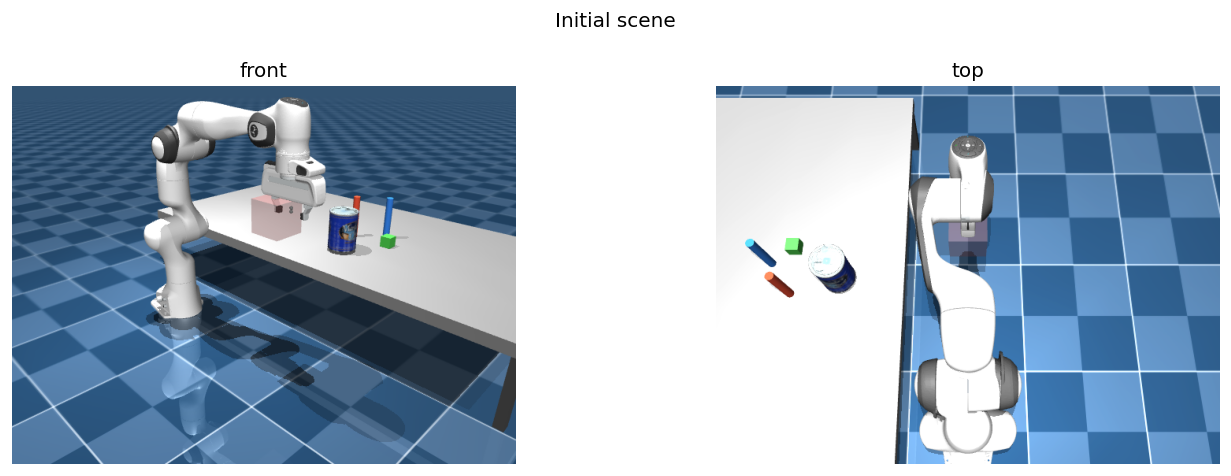

In [40]:
builder = ArmSceneBuilder()
builder.add_resource("table",    TABLE_SYMBOLIC_TEMPLATE)
builder.add_resource("cylinder", CYLINDER_THIN_TEMPLATE)
builder.add_resource("block",    BLOCK_SMALL_TEMPLATE)

builder.add_object("table",    pos=[0.75,  0.80, 0.00])
builder.add_object("cylinder", pos=[0.40,  0.55, 0.35], rgba=[0.9, 0.3, 0.2, 1.0], name="cyl_a")
builder.add_object("cylinder", pos=[0.50, 0.62, 0.35], rgba=[0.2, 0.5, 0.9, 1.0], name="cyl_b")
builder.add_object("block",    pos=[0.55,  0.55, 0.29], rgba=[0.3, 0.8, 0.3, 1.0], name="block_a")

# Remote YCB objects work the same way — downloads and caches automatically:
builder.add_resource("can", {"type": "ycb", "name": "master_chef_can"})
builder.add_object("can", pos=[0.45, 0.40, 0.35], name="can")

env = builder.build_env(rate=200.0)
env.forward()

show_views(env, title="Initial scene")

---
## 2. Inverse Kinematics

`MinkIK` (accessed via `env.get_ik()`) solves for the joint configuration that places the gripper at a target Cartesian pose. We compare home position and IK result side-by-side. You can see the position of the target visualized through a red cube, transparent cube.

IK converged: True
Joint angles [rad]: [-0.1053 -0.1593 -0.0868 -2.0452 -0.0144  1.8864  0.5987]


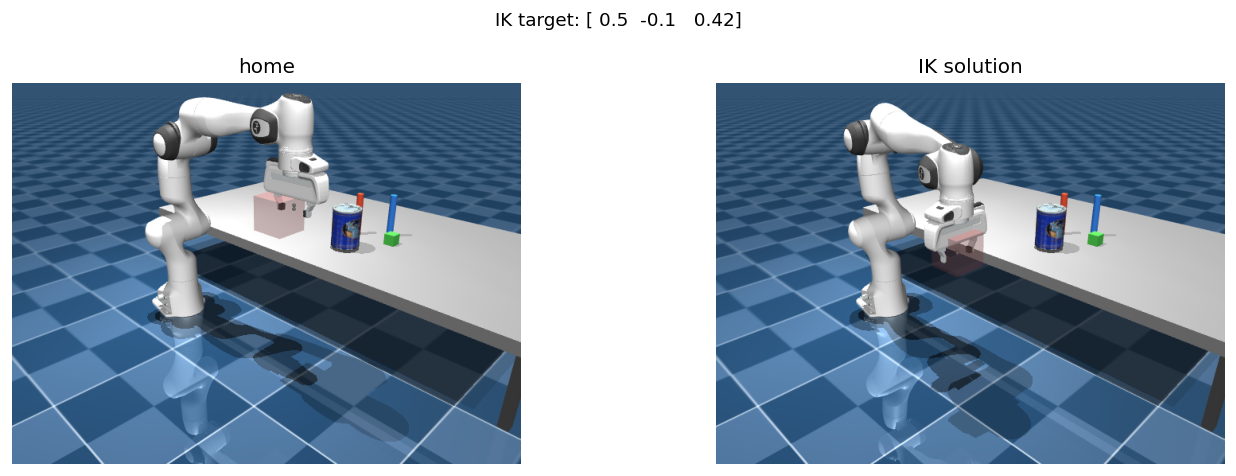

In [41]:
ik = env.get_ik()

reset_scene(env, settle_steps=0)   # arm to home, no settling needed for IK demo
before = render_view(env, azimuth=135, elevation=-25)

target_pos  = np.array([0.50, -0.10, 0.42])
target_quat = np.array([0.00, 1.00, 0.00, 0.00])  # gripper pointing down

ik.set_target_position(target_pos, target_quat)
converged = ik.converge_ik(env.rate.dt)

print(f"IK converged: {converged}")
if converged:
    q = ik.configuration.q[:7]
    print(f"Joint angles [rad]: {np.round(q, 4)}")
    env.data.qpos[:7] = q
    env.forward()

after = render_view(env, azimuth=135, elevation=-25)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(before); axes[0].set_title("home");       axes[0].axis("off")
axes[1].imshow(after);  axes[1].set_title("IK solution"); axes[1].axis("off")
plt.suptitle(f"IK target: {target_pos}", fontsize=11)
plt.tight_layout()
show_fig(fig)

---
## 3. RRT\* Motion Planning

`RRTStar.plan_to_pose` combines IK (to find a valid goal configuration) with RRT\* (to plan a collision-free joint-space path to it). We visualise three snapshots along the path: start, midpoint, and goal.

In [57]:
planner = RRTStar(env)

rrt_target_pos  = np.array([0.10, 0.45, 0.45])
rrt_target_quat = np.array([1.00, 1.00, 1.00, 0.00])

reset_scene(env, settle_steps=0)
print("Planning with RRT* ...")
path = planner.plan_to_pose(rrt_target_pos, rrt_target_quat, dt=env.rate.dt, max_iterations=2000)

if path is not None:
    print(f"Path: {len(path)} waypoints after smoothing")
else:
    print("No path found — try increasing max_iterations")

Planning with RRT* ...
Path: 12 waypoints after smoothing


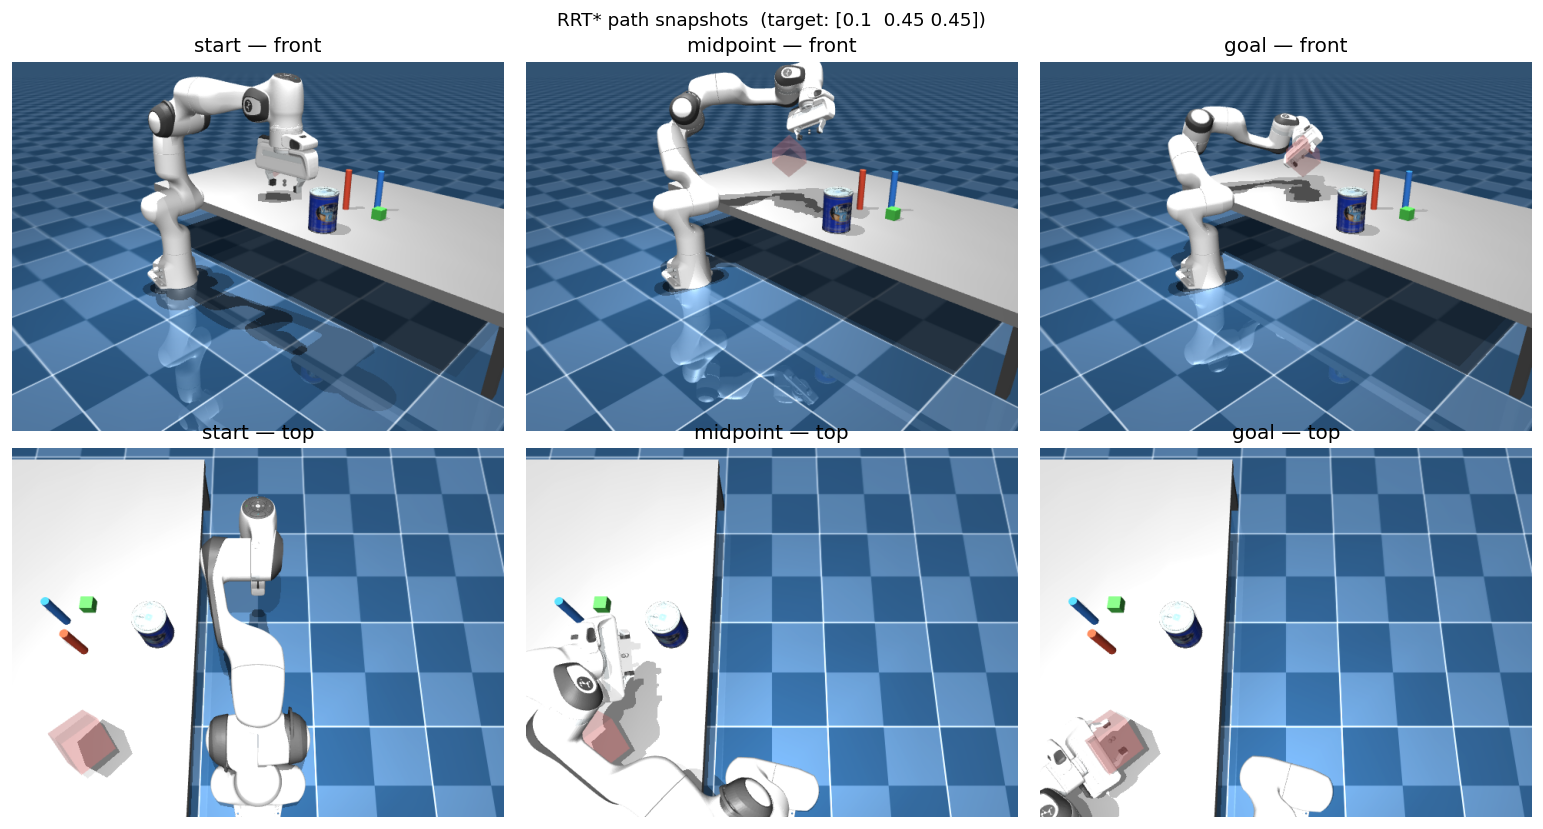

In [58]:
if path is not None:
    snapshots = [0, len(path) // 2, len(path) - 1]
    labels    = ["start", f"midpoint", "goal"]

    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for col, (idx, label) in enumerate(zip(snapshots, labels)):
        env.data.qpos[:7] = path[idx]
        env.forward()
        axes[0][col].imshow(render_view(env, azimuth=135, elevation=-25))
        axes[0][col].set_title(f"{label} — front"); axes[0][col].axis("off")
        axes[1][col].imshow(render_view(env, azimuth=0, elevation=-70))
        axes[1][col].set_title(f"{label} — top");   axes[1][col].axis("off")

    plt.suptitle(f"RRT* path snapshots  (target: {rrt_target_pos})", fontsize=11)
    plt.tight_layout()
    show_fig(fig)

---
## 4. Grasp Planning and Execution

`GraspPlanner` generates ranked grasp candidates from object geometry. Each candidate has three key poses: **approach** (gripper open, above object), **grasp** (contact point), and **lift** (post-grasp raise).

Below we run the full pick sequence manually — plan to approach, descend to grasp, close gripper, attach, lift — to show what happens under the hood.

In [44]:
grasp_planner = GraspPlanner(table_z=0.27)
planner = RRTStar(env)

reset_scene(env)

can_pos  = env.get_object_position("can")
can_half = env.get_object_half_size("can")
can_quat = env.get_object_orientation("can")

candidates = grasp_planner.generate_candidates(can_pos, can_half, can_quat)
print(f"can at {np.round(can_pos, 3)}  half_size={np.round(can_half, 3)}")
for c in candidates:
    print(f"  {c.grasp_type.value:<12}  score={c.score:.0f}")

candidate = next(c for c in candidates if c.grasp_type == GraspType.FRONT)

can at [0.45  0.4   0.341]  half_size=[0.031 0.056 0.051]
  top_down_x    score=25
  front         score=5


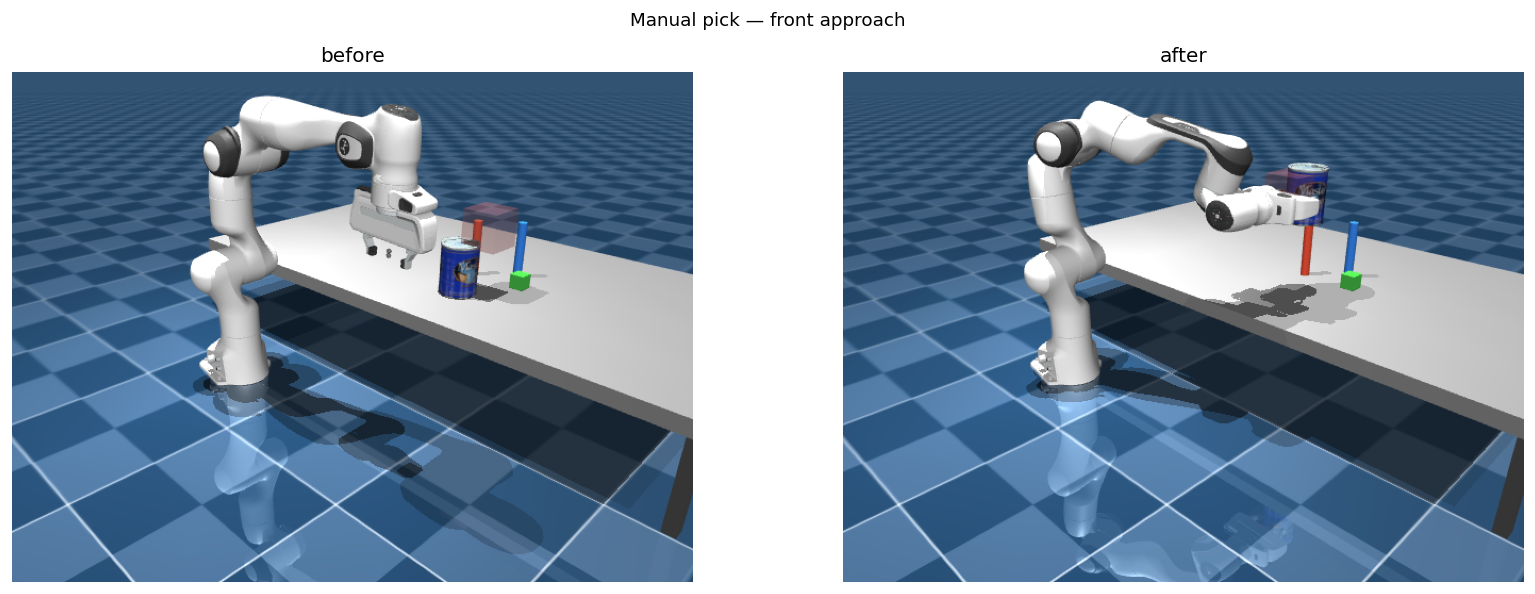

In [45]:
before_img = render_view(env, azimuth=135, elevation=-25)

# 1. Plan and move to approach pose (gripper open)
path = planner.plan_to_pose(candidate.approach_pos, candidate.grasp_quat, dt=0.005, max_iterations=2000)
env.execute_path(path, planner, step_size=0.01)
env.wait_idle()

# 2. Descend to grasp pose (exclude can from collision so the arm can touch it)
env.add_collision_exception("can")
path = planner.plan_to_pose(candidate.grasp_pos, candidate.grasp_quat, dt=0.005, max_iterations=2000)
env.execute_path(path, planner, step_size=0.003)
env.wait_idle()

# 3. Close gripper and wait for fingers to stop
env.controller.close_gripper()
for _ in range(600):
    env.controller.step(); env.step()

# 4. Kinematically attach the can so it rides with the EE during lift
env.attach_object_to_ee("can")

# 5. Lift (can stays excepted — it is now held geometry, not an obstacle)
path = planner.plan_to_pose(candidate.lift_pos, candidate.grasp_quat, dt=0.005, max_iterations=2000)
env.remove_collision_exception("can")
env.execute_path(path, planner, step_size=0.003)
env.wait_idle()
after_img = render_view(env, azimuth=135, elevation=-25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(before_img); axes[0].set_title("before"); axes[0].axis("off")
axes[1].imshow(after_img);  axes[1].set_title("after");  axes[1].axis("off")
plt.suptitle(f"Manual pick — front approach", fontsize=11)
plt.tight_layout()
show_fig(fig)

---
## 5. Pick and Place with `PickPlaceExecutor`

`PickPlaceExecutor` wraps the sequence above into a single call. It generates all grasp candidates, tries them in score order, and handles approach → grasp → lift → transport → place → release automatically.

[PickPlaceExecutor] Trying candidate 1/1: front
  EE error at grasp: 10.0 mm
  pick SUCCESS
[PickPlaceExecutor] place SUCCESS


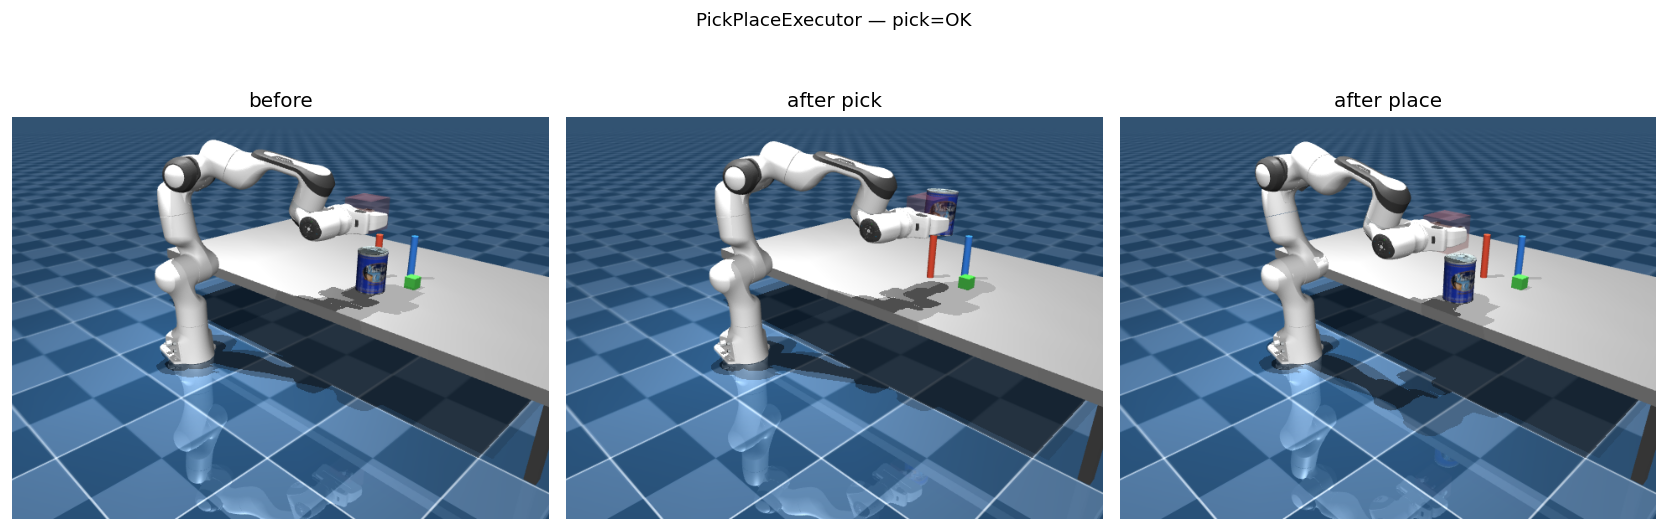

In [46]:
executor = PickPlaceExecutor(env, planner, grasp_planner, use_attachment=True)

reset_scene(env)

can_candidates = grasp_planner.generate_candidates(
    env.get_object_position("can"),
    env.get_object_half_size("can"),
    env.get_object_orientation("can"),
)
front = [c for c in can_candidates if c.grasp_type == GraspType.FRONT]

before_img = render_view(env, azimuth=135, elevation=-25)
ok = executor.pick(
    "can",
    env.get_object_position("can"),
    env.get_object_half_size("can"),
    env.get_object_orientation("can"),
    candidates=front,
)
after_pick_img = render_view(env, azimuth=135, elevation=-25)

# Keep the same EE orientation as the pick throughout transport and place.
# Switching orientation while the can is attached would rotate it in the gripper.
place_pos = np.array([0.45, 0.25, 0.34])
if ok:
    executor.place("can", place_pos, front[0].grasp_quat)
after_place_img = render_view(env, azimuth=135, elevation=-25)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(before_img); axes[0].set_title("before"); axes[0].axis("off")
axes[1].imshow(after_pick_img);  axes[1].set_title("after pick"); axes[1].axis("off")
axes[2].imshow(after_place_img);  axes[2].set_title("after place"); axes[2].axis("off")
plt.suptitle(f"PickPlaceExecutor — pick={'OK' if ok else 'FAILED'}", fontsize=11)
plt.tight_layout()
show_fig(fig)

---
## Next Steps

| What you want | Where to look |
|---------------|---------------|
| Live viewer demos | `mjpython examples/basic_ik.py`, `basic_rrt.py` |
| Grasping in viewer | `mjpython examples/grasping_rrt_planner.py` |
| Full pick-and-place | `mjpython examples/blocks_world_rrt.py` |
| PDDL symbolic planning | `mjpython examples/symbolic.py` |
| Dataset generation | `python -m tampanda.symbolic.domains.tabletop.generate_data --help` |
| Mobile robot | `notebooks/mobile_getting_started.ipynb` |